# Netflix Data Analysis
### Python | Pandas | NumPy | Matplotlib | Seaborn

**Author:** Dev Bhardwaj
**Project timeline:** January 2026 – February 2026

## Objective
Analyze the Netflix Movies and TV Shows dataset (8,800+ titles) to uncover
patterns in content type, genre distribution, release trends, country of
production, ratings, and duration — and translate those patterns into
business-relevant insights.

## Dataset
- **Source:** Netflix Movies and TV Shows dataset (originally published on Kaggle by Shivam Bansal)
- **Records:** 8,807 titles
- **Columns:** `show_id`, `type`, `title`, `director`, `cast`, `country`, `date_added`, `release_year`, `rating`, `duration`, `listed_in`, `description`


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#221F1F"


## 1. Data Loading

In [2]:
df = pd.read_csv("../data/netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names:", list(df.columns))


Dataset shape: (8807, 12)

Column names: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [4]:
df.dtypes


show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observation:** The dataset contains **8,807 titles** with **12 original columns**, matching the target of 8,000+ Netflix titles for this analysis.

## 2. Data Cleaning

We check for missing values, duplicates, inconsistent text, invalid years,
and convert `date_added` to a proper datetime type.

In [6]:
shape_before = df.shape
print("Shape before cleaning:", shape_before)

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_report


Shape before cleaning: (8807, 12)


,missing_count,missing_pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


In [7]:
# Check for duplicate rows
dup_count = df.duplicated().sum()
dup_titles = df.duplicated(subset=["title", "type"]).sum()
print("Fully duplicate rows:", dup_count)
print("Duplicate (title, type) combinations:", dup_titles)

df = df.drop_duplicates()
df = df.drop_duplicates(subset=["title", "type"])


Fully duplicate rows: 0
Duplicate (title, type) combinations: 0


In [8]:
# Clean whitespace / inconsistent text on key text columns
text_cols = ["type", "title", "director", "cast", "country", "rating", "listed_in"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({"nan": np.nan, "": np.nan})

# Handle missing categorical values
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])


In [9]:
# Convert date_added to datetime
df["date_added"] = df["date_added"].astype(str).str.strip()
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

# Check for invalid release years
current_year = 2026
invalid_years = df[(df["release_year"] < 1900) | (df["release_year"] > current_year)]
print("Invalid release_year values found:", len(invalid_years))


Invalid release_year values found: 0


In [10]:
# Parse duration into a numeric value, split by content type
df["duration"] = df["duration"].astype(str).str.strip()
df.loc[df["duration"] == "nan", "duration"] = np.nan
print("Missing duration values:", df["duration"].isnull().sum())

def parse_duration(row):
    dur = row["duration"]
    if pd.isna(dur):
        return np.nan
    digits = "".join(ch for ch in dur if ch.isdigit())
    return float(digits) if digits else np.nan

df["duration_value"] = df.apply(parse_duration, axis=1)
df["duration_minutes"] = np.where(df["type"] == "Movie", df["duration_value"], np.nan)
df["duration_seasons"] = np.where(df["type"] == "TV Show", df["duration_value"], np.nan)

# Fill missing movie duration with the median
movie_median = df.loc[df["type"] == "Movie", "duration_minutes"].median()
df.loc[df["type"] == "Movie", "duration_minutes"] = df.loc[df["type"] == "Movie", "duration_minutes"].fillna(movie_median)

df["primary_country"] = df["country"].apply(lambda x: x.split(",")[0].strip() if isinstance(x, str) else x)


Missing duration values: 3


In [11]:
shape_after = df.shape
print("Shape before cleaning:", shape_before)
print("Shape after cleaning:", shape_after)
print("Rows removed during cleaning:", shape_before[0] - shape_after[0])

df[["director", "cast", "country", "rating", "duration"]].isnull().sum()


Shape before cleaning: (8807, 12)
Shape after cleaning: (8807, 18)
Rows removed during cleaning: 0


director    0
cast        0
country     0
rating      0
duration    3
dtype: int64

**Observation:** No fully duplicate rows or duplicate (title, type) combinations were found. Missing values were concentrated in `director` (29.9%), `country` (9.4%), and `cast` (9.4%) — all handled by filling with `'Unknown'` rather than dropping rows, preserving the full 8,807-record dataset for analysis.

## 3. Exploratory Data Analysis

### 3.1 Content Type — Movies vs TV Shows

In [12]:
type_counts = df["type"].value_counts()
type_pct = (type_counts / len(df) * 100).round(2)
print(type_counts)
print()
print(type_pct)


type
Movie      6131
TV Show    2676
Name: count, dtype: int64

type
Movie      69.62
TV Show    30.38
Name: count, dtype: float64


/tmp/ipykernel_583/2944393671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette=[NETFLIX_RED, NETFLIX_DARK], ax=axes[0])


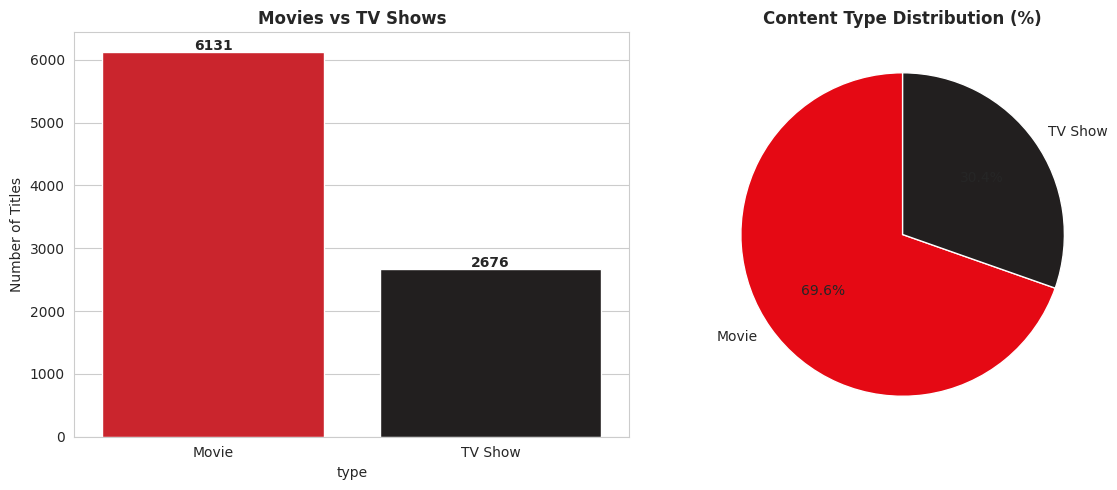

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=type_counts.index, y=type_counts.values, palette=[NETFLIX_RED, NETFLIX_DARK], ax=axes[0])
axes[0].set_title("Movies vs TV Shows", fontweight="bold")
axes[0].set_ylabel("Number of Titles")
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

axes[1].pie(type_pct.values, labels=type_pct.index, autopct="%1.1f%%",
            colors=[NETFLIX_RED, NETFLIX_DARK], startangle=90)
axes[1].set_title("Content Type Distribution (%)", fontweight="bold")

plt.tight_layout()
plt.savefig("../visualizations/01_movies_vs_tvshows_bar.png", bbox_inches="tight")
plt.show()


**Insight:** Movies make up roughly **70%** of Netflix's catalog vs **30%** for TV Shows — the platform's library skews heavily toward movies, even though TV Shows have been growing faster in recent years (see below).

### 3.2 Release Trends

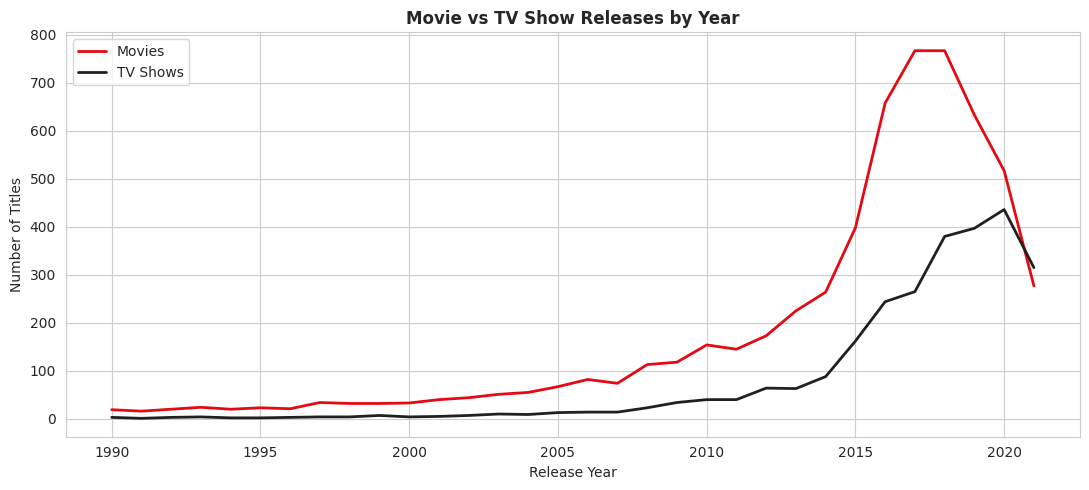

In [14]:
year_counts = df["release_year"].value_counts().sort_index()
year_type_counts = df.groupby(["release_year", "type"]).size().unstack(fill_value=0)

recent = year_type_counts[year_type_counts.index >= 1990]

plt.figure(figsize=(11, 5))
plt.plot(recent.index, recent["Movie"], label="Movies", color=NETFLIX_RED, linewidth=2)
plt.plot(recent.index, recent["TV Show"], label="TV Shows", color=NETFLIX_DARK, linewidth=2)
plt.title("Movie vs TV Show Releases by Year", fontweight="bold")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/04_movie_vs_tv_release_trend.png", bbox_inches="tight")
plt.show()


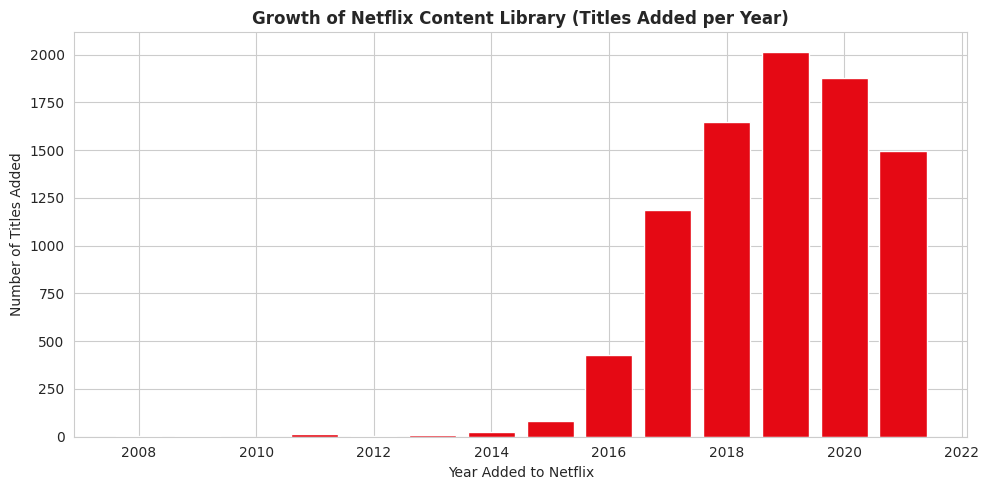

In [15]:
added_counts = df["year_added"].value_counts().sort_index()
added_counts = added_counts[added_counts.index >= 2008]

plt.figure(figsize=(10, 5))
plt.bar(added_counts.index.astype(int), added_counts.values, color=NETFLIX_RED)
plt.title("Growth of Netflix Content Library (Titles Added per Year)", fontweight="bold")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.savefig("../visualizations/12_content_added_growth.png", bbox_inches="tight")
plt.show()


**Insight:** Content releases rose sharply after 2015 and peaked around 2018–2019, followed by a decline — consistent with a slowdown in additions after 2020. TV Show output has grown at a faster relative rate than movies in the most recent years, narrowing the historical gap.

### 3.3 Genre Analysis

In [16]:
genre_long = df[["show_id", "type", "listed_in"]].copy()
genre_long["genre"] = genre_long["listed_in"].str.split(",")
genre_long = genre_long.explode("genre")
genre_long["genre"] = genre_long["genre"].str.strip()

genre_counts = genre_long["genre"].value_counts()
top10_genres = genre_counts.head(10)
print("Number of unique genres:", genre_counts.shape[0])
top10_genres


Number of unique genres: 42


genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

/tmp/ipykernel_583/3908990031.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_genres.values, y=top10_genres.index, palette="Reds_r")


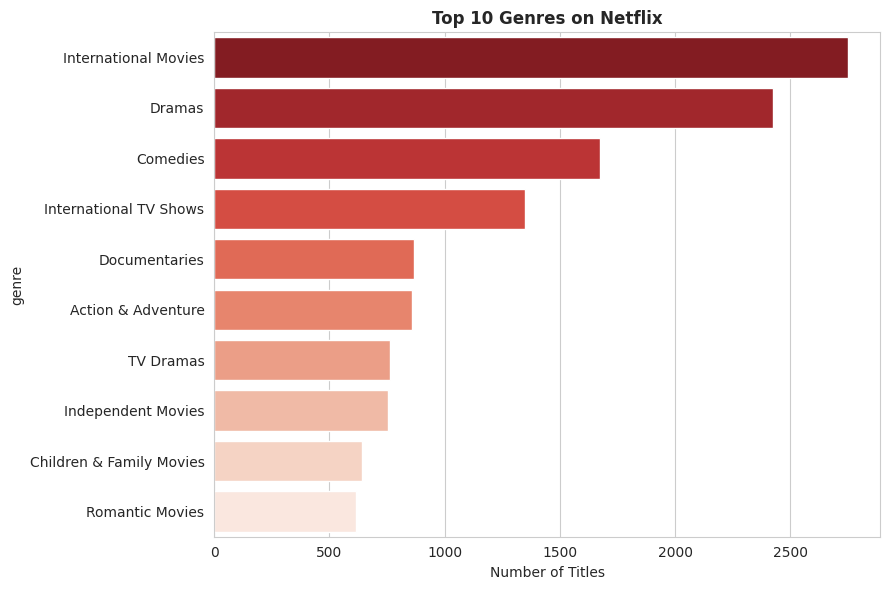

In [17]:
plt.figure(figsize=(9, 6))
sns.barplot(x=top10_genres.values, y=top10_genres.index, palette="Reds_r")
plt.title("Top 10 Genres on Netflix", fontweight="bold")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.savefig("../visualizations/05_top10_genres.png", bbox_inches="tight")
plt.show()


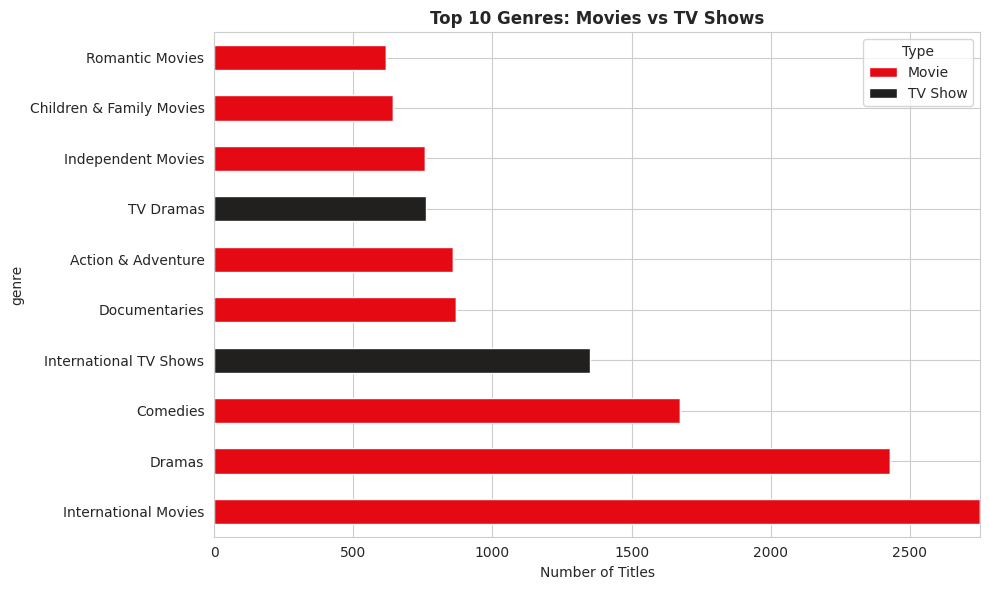

In [18]:
genre_by_type = genre_long.groupby(["type", "genre"]).size().unstack(level=0, fill_value=0)
gbt = genre_by_type.reindex(top10_genres.index).fillna(0)

plt.figure(figsize=(10, 6))
gbt.plot(kind="barh", stacked=True, color=[NETFLIX_RED, NETFLIX_DARK], ax=plt.gca())
plt.title("Top 10 Genres: Movies vs TV Shows", fontweight="bold")
plt.xlabel("Number of Titles")
plt.legend(title="Type")
plt.tight_layout()
plt.savefig("../visualizations/14_genre_by_content_type.png", bbox_inches="tight")
plt.show()


**Insight:** International Movies and Dramas dominate Netflix's genre mix, reflecting a strategy of localized, globally-relevant content. Documentaries and International TV Shows also rank highly, showing investment beyond mainstream scripted entertainment.

### 3.4 Country Analysis

In [19]:
country_long = df[["show_id", "type", "country"]].copy()
country_long = country_long[country_long["country"] != "Unknown"]
country_long["country_split"] = country_long["country"].str.split(",")
country_long = country_long.explode("country_split")
country_long["country_split"] = country_long["country_split"].str.strip()

country_counts = country_long["country_split"].value_counts()
top10_countries = country_counts.head(10)
print("Number of countries represented:", country_counts.shape[0])
top10_countries


Number of countries represented: 123


country_split
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

/tmp/ipykernel_583/319614204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_countries.values, y=top10_countries.index, palette="Reds_r")


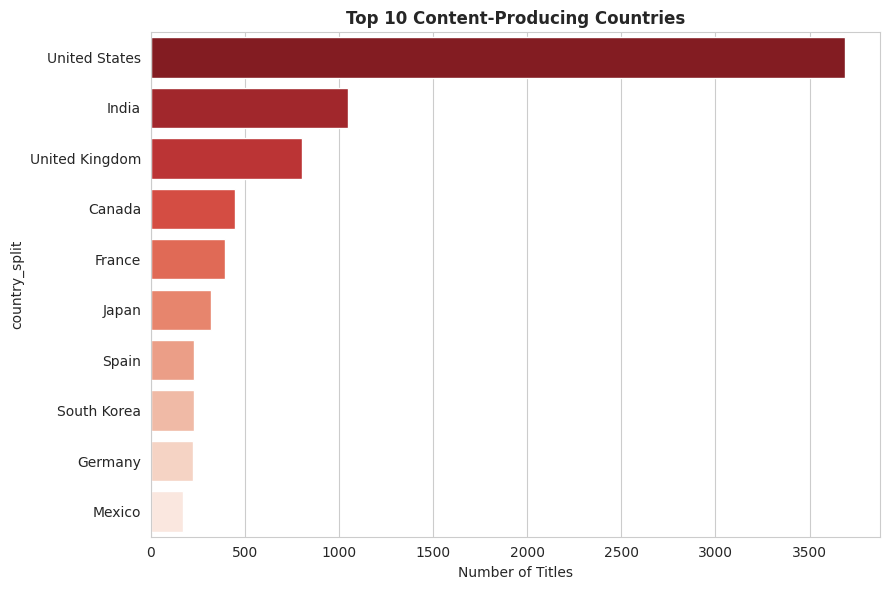

In [20]:
plt.figure(figsize=(9, 6))
sns.barplot(x=top10_countries.values, y=top10_countries.index, palette="Reds_r")
plt.title("Top 10 Content-Producing Countries", fontweight="bold")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.savefig("../visualizations/06_top10_countries.png", bbox_inches="tight")
plt.show()


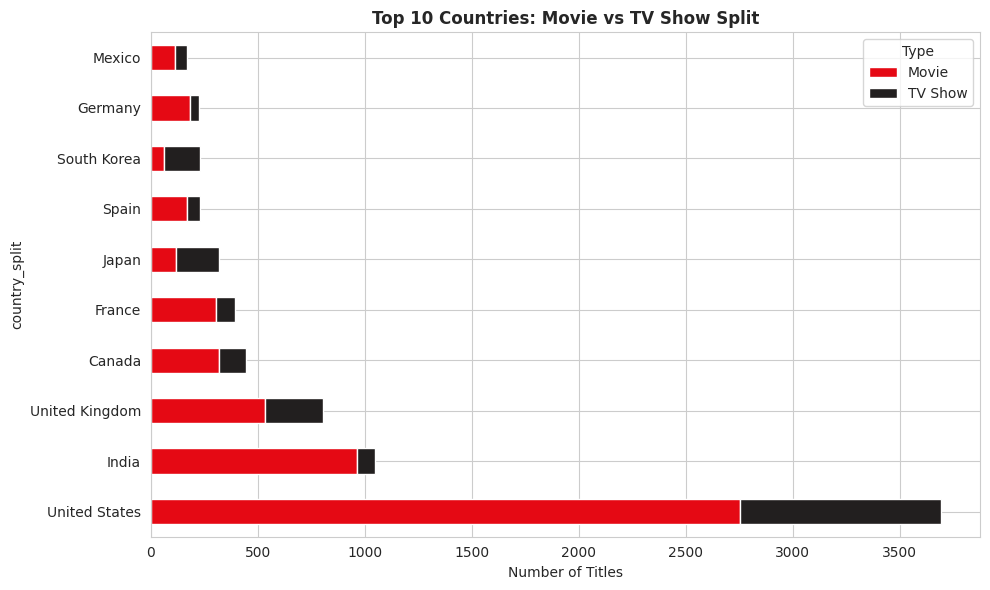

In [21]:
country_type = country_long.groupby(["country_split", "type"]).size().unstack(fill_value=0)
ct = country_type.loc[top10_countries.index]

plt.figure(figsize=(10, 6))
ct.plot(kind="barh", stacked=True, color=[NETFLIX_RED, NETFLIX_DARK], ax=plt.gca())
plt.title("Top 10 Countries: Movie vs TV Show Split", fontweight="bold")
plt.xlabel("Number of Titles")
plt.legend(title="Type")
plt.tight_layout()
plt.savefig("../visualizations/13_country_content_type_split.png", bbox_inches="tight")
plt.show()


**Insight:** The United States is the largest content producer by a wide margin, followed by India and the United Kingdom. India's strong presence reflects Netflix's continued investment in regional-language content for its second-largest global market.

### 3.5 Content Ratings

In [22]:
rating_counts = df["rating"].value_counts()
rating_by_type = df.groupby(["rating", "type"]).size().unstack(fill_value=0)
rating_counts


rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

/tmp/ipykernel_583/2476399658.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="Reds_r")


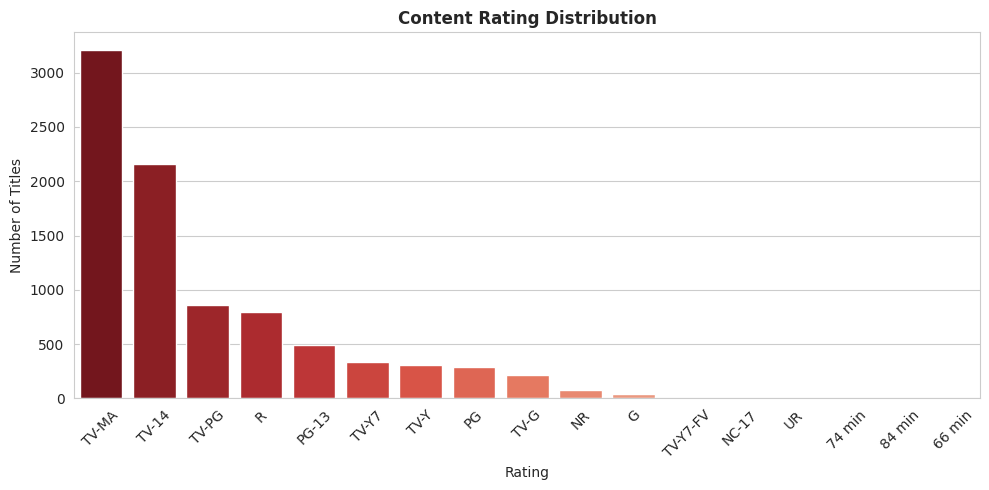

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="Reds_r")
plt.title("Content Rating Distribution", fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visualizations/07_rating_distribution.png", bbox_inches="tight")
plt.show()


**Insight:** `TV-MA` (mature audiences) is the most common rating, followed by `TV-14`, showing that Netflix's catalog leans toward teen/adult-oriented content rather than family programming.

### 3.6 Movie Duration

In [24]:
movie_durations = df.loc[df["type"] == "Movie", "duration_minutes"].dropna()
print("Mean duration:", round(movie_durations.mean(), 1), "min")
print("Min duration:", movie_durations.min(), "min")
print("Max duration:", movie_durations.max(), "min")
print("Most common duration range:", pd.cut(movie_durations, bins=range(0, 330, 30)).value_counts().idxmax())


Mean duration: 99.6 min
Min duration: 3.0 min
Max duration: 312.0 min
Most common duration range: (90, 120]


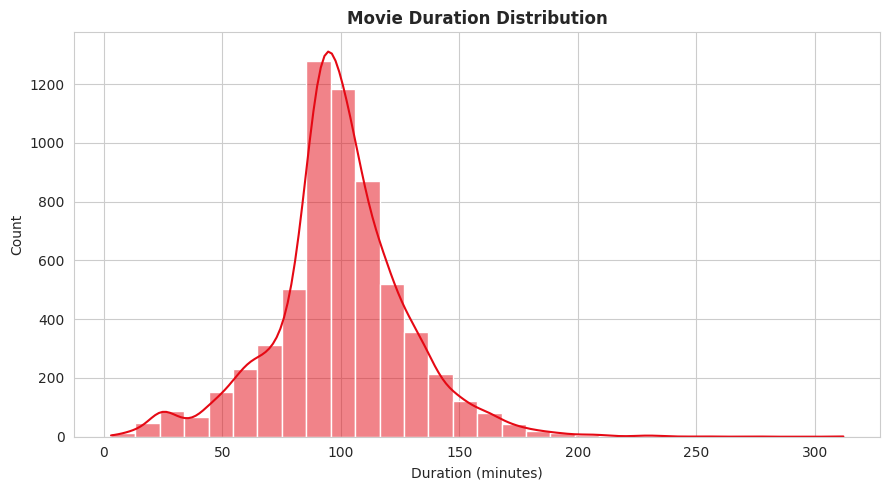

In [25]:
plt.figure(figsize=(9, 5))
sns.histplot(movie_durations, bins=30, color=NETFLIX_RED, kde=True)
plt.title("Movie Duration Distribution", fontweight="bold")
plt.xlabel("Duration (minutes)")
plt.tight_layout()
plt.savefig("../visualizations/08_movie_duration_distribution.png", bbox_inches="tight")
plt.show()


**Insight:** The typical Netflix movie runs close to 100 minutes, in line with standard theatrical-length films, with the bulk of titles falling between 80–120 minutes.

### 3.7 TV Show Seasons

In [26]:
tv_seasons = df.loc[df["type"] == "TV Show", "duration_seasons"].dropna()
print("Mean seasons:", round(tv_seasons.mean(), 2))
print("Most common season count:", int(tv_seasons.mode()[0]))


Mean seasons: 1.76
Most common season count: 1


/tmp/ipykernel_583/1679479328.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_counts.index.astype(int), y=season_counts.values, palette="Reds_r")


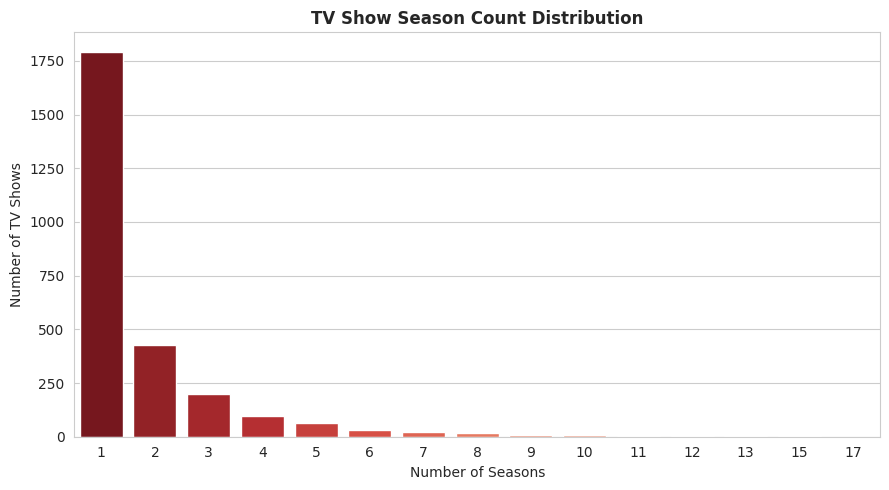

In [27]:
season_counts = tv_seasons.value_counts().sort_index()

plt.figure(figsize=(9, 5))
sns.barplot(x=season_counts.index.astype(int), y=season_counts.values, palette="Reds_r")
plt.title("TV Show Season Count Distribution", fontweight="bold")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.tight_layout()
plt.savefig("../visualizations/09_tvshow_season_distribution.png", bbox_inches="tight")
plt.show()


**Insight:** The vast majority of Netflix TV Shows have only **1 season**, suggesting most series are either newly launched, limited series, or were not renewed — a useful signal about content renewal strategy.

### 3.8 Directors

In [28]:
directors = df[df["director"] != "Unknown"]["director"]
director_split = directors.str.split(",").explode().str.strip()
top10_directors = director_split.value_counts().head(10)
top10_directors


director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

/tmp/ipykernel_583/180974951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_directors.values, y=top10_directors.index, palette="Reds_r")


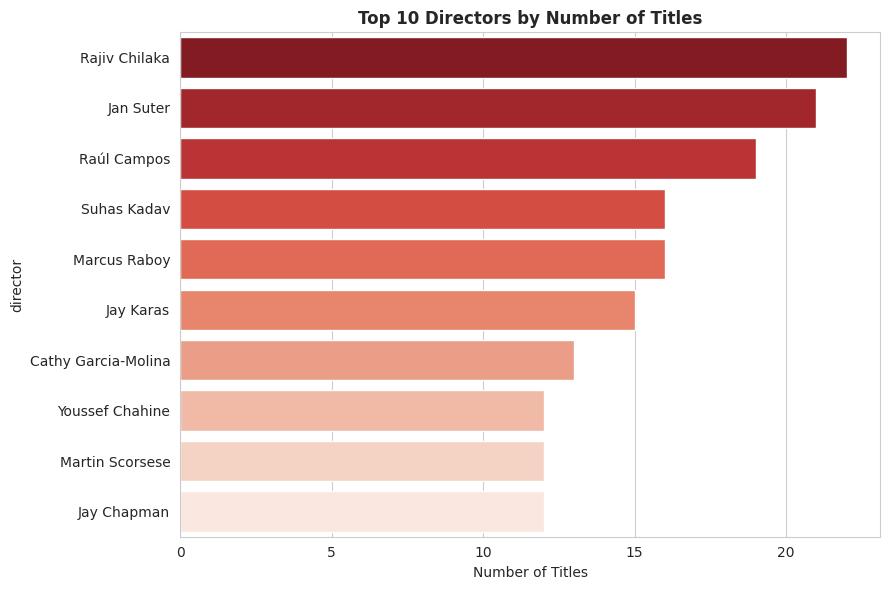

In [29]:
plt.figure(figsize=(9, 6))
sns.barplot(x=top10_directors.values, y=top10_directors.index, palette="Reds_r")
plt.title("Top 10 Directors by Number of Titles", fontweight="bold")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.savefig("../visualizations/10_top10_directors.png", bbox_inches="tight")
plt.show()


**Insight:** Directors such as Rajiv Chilaka (Indian animated content) and Jan Suter / Raúl Campos (Latin American comedy specials) appear most frequently, reflecting Netflix's investment in prolific regional content partners.

### 3.9 Cast

In [30]:
cast_long = df[["show_id", "cast"]].copy()
cast_long = cast_long[cast_long["cast"] != "Unknown"]
cast_long["actor"] = cast_long["cast"].str.split(",")
cast_long = cast_long.explode("actor")
cast_long["actor"] = cast_long["actor"].str.strip()

top10_actors = cast_long["actor"].value_counts().head(10)
top10_actors


actor
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

**Insight:** Indian actors (Anupam Kher, Shah Rukh Khan, Naseeruddin Shah, Akshay Kumar, Amitabh Bachchan) dominate the most-frequent-cast list — a direct reflection of the large volume of Indian film and TV content in the catalog.

## 4. Additional Visualizations

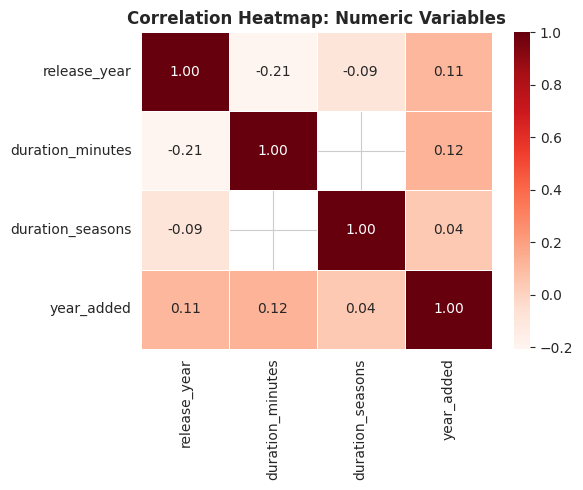

In [31]:
plt.figure(figsize=(6, 5))
numeric_df = df[["release_year", "duration_minutes", "duration_seasons", "year_added"]]
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="Reds", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Numeric Variables", fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/15_correlation_heatmap.png", bbox_inches="tight")
plt.show()


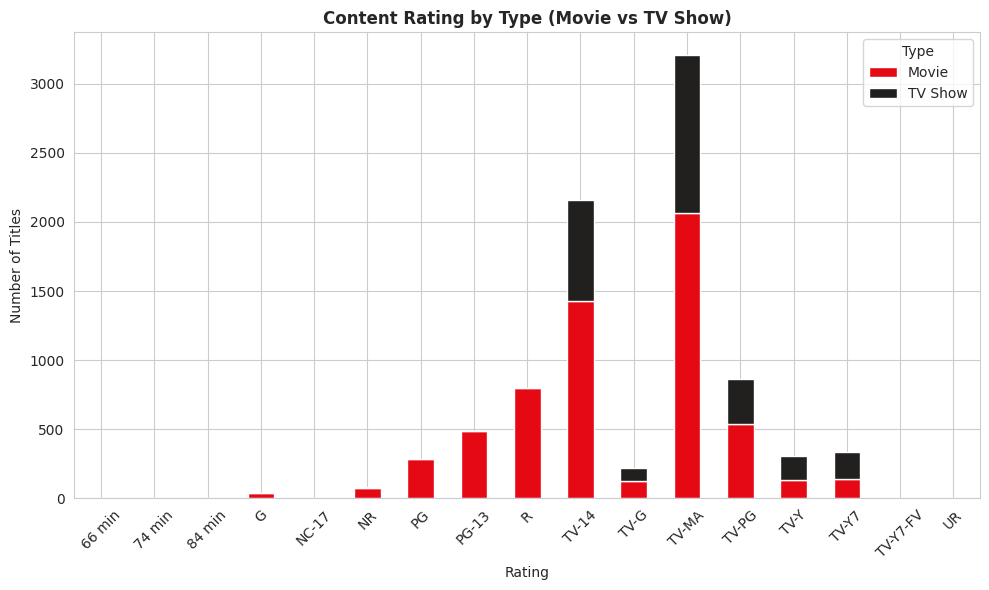

In [32]:
rating_by_type.plot(kind="bar", stacked=True, figsize=(10, 6), color=[NETFLIX_RED, NETFLIX_DARK])
plt.title("Content Rating by Type (Movie vs TV Show)", fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Type")
plt.tight_layout()
plt.savefig("../visualizations/11_rating_by_content_type.png", bbox_inches="tight")
plt.show()


## 5. Statistical Summary

In [33]:
total_titles = len(df)
total_movies = int(type_counts.get("Movie", 0))
total_tv = int(type_counts.get("TV Show", 0))
movie_pct = round(total_movies / total_titles * 100, 2)
tv_pct = round(total_tv / total_titles * 100, 2)
unique_genres = df["listed_in"].str.split(",").explode().str.strip().nunique()
unique_countries = country_counts.shape[0]
avg_movie_duration = round(movie_durations.mean(), 1)
avg_tv_seasons = round(tv_seasons.mean(), 2)
earliest_year = int(df["release_year"].min())
latest_year = int(df["release_year"].max())

summary = {
    "Total titles": total_titles,
    "Total movies": total_movies,
    "Total TV shows": total_tv,
    "Movie percentage": f"{movie_pct}%",
    "TV Show percentage": f"{tv_pct}%",
    "Number of unique genres": unique_genres,
    "Number of countries": unique_countries,
    "Average movie duration (min)": avg_movie_duration,
    "Average TV show seasons": avg_tv_seasons,
    "Earliest release year": earliest_year,
    "Latest release year": latest_year,
}

pd.Series(summary)


Total titles                      8807
Total movies                      6131
Total TV shows                    2676
Movie percentage                69.62%
TV Show percentage              30.38%
Number of unique genres             42
Number of countries                123
Average movie duration (min)      99.6
Average TV show seasons           1.76
Earliest release year             1925
Latest release year               2021
dtype: object

## 6. Key Findings

1. **Movies dominate the library** — Movies account for ~70% of all titles (6,131), vs ~30% for TV Shows (2,676).
2. **International Movies and Dramas are the top genres**, reflecting Netflix's global-content strategy.
3. **The United States leads content production** (3,690 titles), followed by India (1,046) and the United Kingdom (806).
4. **Content additions grew sharply between 2015–2019**, then declined — likely tied to strategy shifts and pandemic-era production slowdowns.
5. **TV-MA is the most common content rating**, indicating a catalog skewed toward mature/adult audiences rather than family content.
6. **The average movie runs ~100 minutes**, consistent with standard theatrical run-times.
7. **~1.8 seasons is the average for TV shows**, and a single season is by far the most common outcome — most series are limited runs or not renewed.
8. **India-linked talent dominates the most-frequent-cast list**, reflecting the scale of Indian film/TV content on the platform.
9. **Regional content directors** (e.g., Rajiv Chilaka, Jan Suter, Raúl Campos) appear more frequently than any single Hollywood director, showing investment in high-volume regional production partners.
10. **TV Show output is growing faster than movie output in recent years**, narrowing the historical content-type gap even though movies still dominate overall volume.


## 7. Conclusion

This analysis of 8,807 Netflix titles shows a catalog historically anchored in movies but increasingly diversified with international and TV content. Genre and country patterns point to a deliberate globalization strategy, while rating and duration patterns suggest a platform oriented toward mature, feature-length storytelling. These insights could inform content acquisition, regional investment, and catalog-balance decisions.
